In [ ]:
# Importing few libraries
import os
import shutil
import random
from tqdm import tqdm

import numpy as np
import pandas as pd
import cv2

import PIL
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
!pip install kaggle


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ranaaziz91","key":"b42678124e1ea52268acc6608cdc656b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d apollo2506/eurosat-dataset


Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:34<00:00, 34.0MB/s]
100% 2.04G/2.04G [00:34<00:00, 64.2MB/s]


In [ ]:
!unzip -q eurosat-dataset.zip -d /content/EuroSAT


In [ ]:
import os

# Define dataset path
DATASET = "/content/EuroSAT/EuroSAT"

if os.path.exists(DATASET):
    print("✅ Folder found! Contents inside EuroSAT:")
    for item in os.listdir(DATASET)[:10]:
        print("📁", item)
else:
    print(" Folder not found! Check the path.")


✅ Folder found! Contents inside EuroSAT:
📁 test.csv
📁 SeaLake
📁 Industrial
📁 Pasture
📁 Forest
📁 HerbaceousVegetation
📁 Residential
📁 River
📁 Highway
📁 PermanentCrop


### 1. Data Exploration

- Defined the dataset path and ensured correct directory structure (`./SAT/EuroSAT`).
- Loaded the `train.csv`, `validation.csv`, and `test.csv` files to confirm the dataset was pre-split.
- Calculated:
  - Total number of samples across all splits.
  - The count and percentage of samples in each subset (Train, Validation, Test).
- Visualized the dataset split using:
  - **Pie chart** – showing the proportion of each subset.

- Listed all class folders within the dataset and counted the number of images per class.
- Plotted a **bar chart** showing the class distribution across the ten land-cover categories.
- Displayed random **sample images** (two per class) to observe visual differences between classes such as *Forest*, *AnnualCrop*, *Residential*, etc.
- Observed the dataset’s diversity and potential visual overlaps between certain categories (e.g., *Highway* vs *Industrial*).


In [ ]:
# Load the CSV files
train_df = pd.read_csv(os.path.join(DATASET, "train.csv"))
val_df = pd.read_csv(os.path.join(DATASET, "validation.csv"))
test_df = pd.read_csv(os.path.join(DATASET, "test.csv"))

# Count number of samples in each split
train_count = len(train_df)
val_count = len(val_df)
test_count = len(test_df)

# Calculate total
total_count = train_count + val_count + test_count

# Calculate ratios
train_ratio = train_count / total_count * 100
val_ratio = val_count / total_count * 100
test_ratio = test_count / total_count * 100

# Print detailed summary
print("===== Dataset Split Summary =====")
print(f"Total samples: {total_count}")
print(f"Train samples: {train_count} ({train_ratio:.2f}%)")
print(f"Validation samples: {val_count} ({val_ratio:.2f}%)")
print(f"Test samples: {test_count} ({test_ratio:.2f}%)")


===== Dataset Split Summary =====
Total samples: 27000
Train samples: 18900 (70.00%)
Validation samples: 5400 (20.00%)
Test samples: 2700 (10.00%)


Text(0.5, 1.0, 'Dataset Split (Pie Chart)')

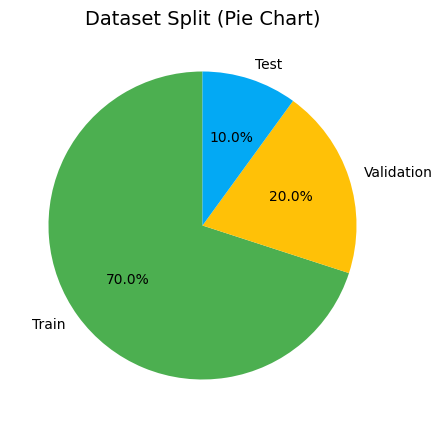

In [ ]:
# Import libraries for plotting
import matplotlib.pyplot as plt

# Define counts and labels
splits = ['Train', 'Validation', 'Test']
counts = [train_count, val_count, test_count]
colors = ['#4CAF50', '#FFC107', '#03A9F4']  # green, yellow, blue

# Create a figure with two subplots side by side
plt.figure(figsize=(12, 5))

# ---------- Pie Chart ----------
plt.subplot(1, 2, 1)
plt.pie(counts, labels=splits, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Dataset Split (Pie Chart)', fontsize=14)


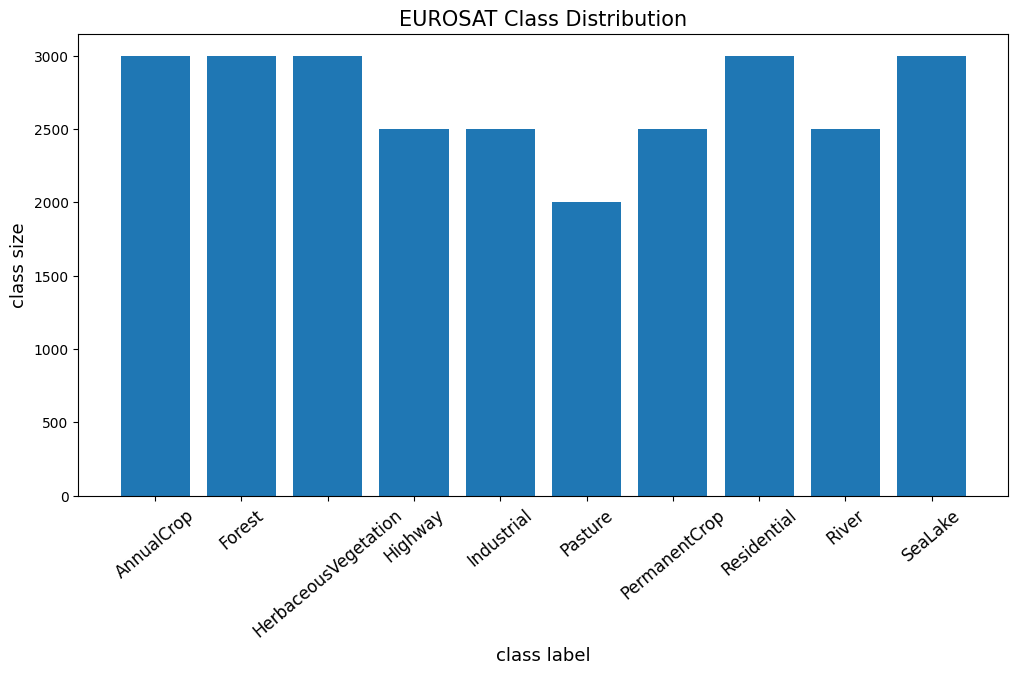

In [ ]:

# List only class folders inside the dataset (ignore CSV/JSON files)
LABELS = [d for d in sorted(os.listdir(DATASET)) if os.path.isdir(os.path.join(DATASET, d))]

# Initialize a dictionary to hold image counts per class
counts = {}

# Count image files inside each class folder
for l in LABELS:
    # Build the absolute path to the class folder
    class_dir = os.path.join(DATASET, l)
    # Count only image files (avoid any non-image files)
    n_imgs = sum(f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff")) for f in os.listdir(class_dir))
    # Store the count for this class
    counts[l] = n_imgs

# Create a new figure with the desired size
plt.figure(figsize=(12, 6))

# Draw a bar chart using the counts dictionary
plt.bar(range(len(counts)), list(counts.values()), align='center')

# Put class names on the x-axis with rotation for readability
plt.xticks(range(len(counts)), list(counts.keys()), fontsize=12, rotation=40)

# Label the axes
plt.xlabel('class label', fontsize=13)
plt.ylabel('class size', fontsize=13)

# Add a title to the plot
plt.title('EUROSAT Class Distribution', fontsize=15)

# Render the plot
plt.show()


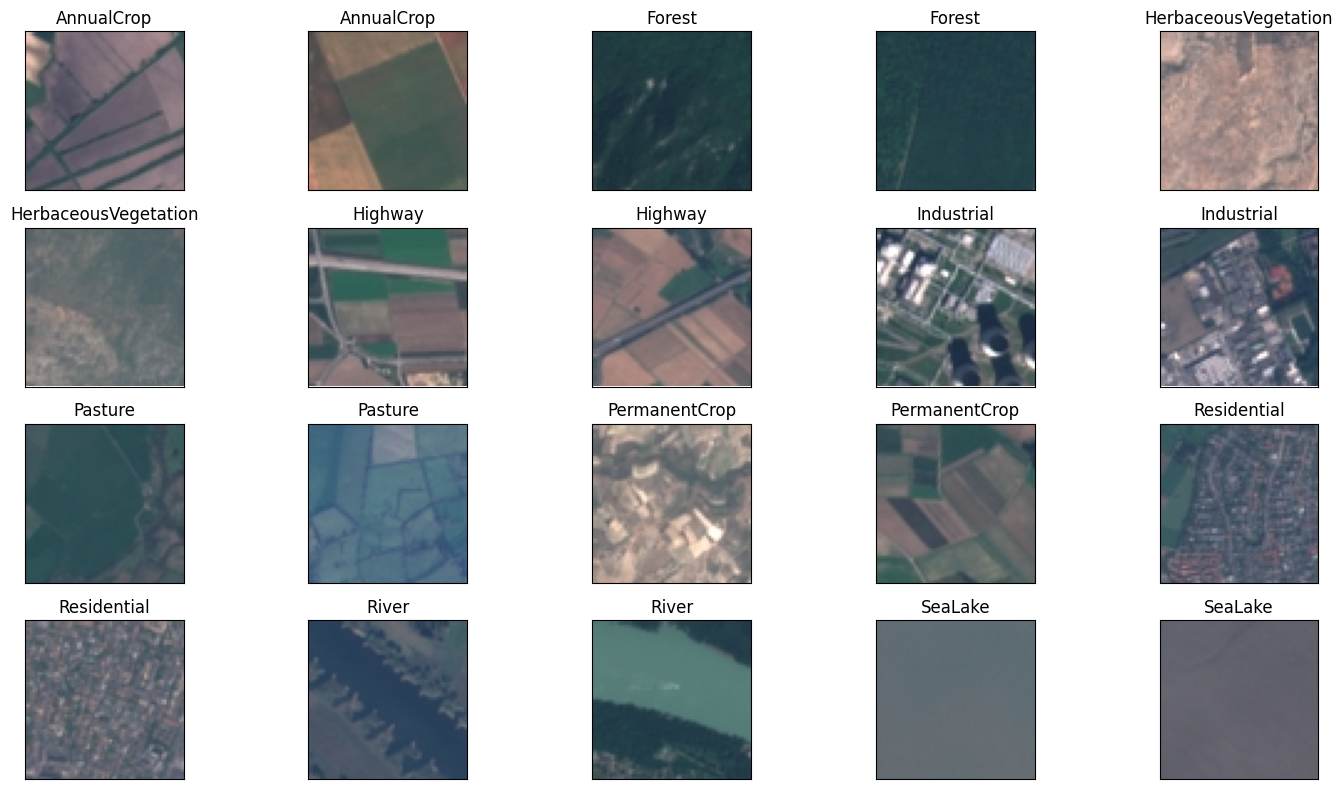

In [ ]:
# Build a list of image paths (two samples per class)
img_paths = []

# Loop through each class folder
for l in LABELS:
    # Get the full path to the class folder
    class_dir = os.path.join(DATASET, l)
    # List all image files inside this class
    files = [f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))]
    # Randomly select up to two images from this class
    selected = random.sample(files, min(2, len(files)))
    # Add their full paths to img_paths
    img_paths += [os.path.join(class_dir, f) for f in selected]

# Define a function to plot satellite images
def plot_sat_imgs(paths):
    plt.figure(figsize=(15, 8))
    for i in range(len(paths)):
        plt.subplot(4, 5, i+1, xticks=[], yticks=[])
        img = PIL.Image.open(paths[i], 'r')
        plt.imshow(np.asarray(img))
        plt.title(paths[i].split(os.sep)[-2])  # use os.sep for cross-platform path splitting
    plt.tight_layout()
    plt.show()

# Plot the selected images
plot_sat_imgs(img_paths)


###  Data Exploration Results & Observations

- The EuroSAT dataset contains a total of **27,000 satellite images** distributed across **10 land-cover classes**.  
- The data is already divided into three subsets:
  - **Training set:** 18,900 images (70%)
  - **Validation set:** 5,400 images (20%)
  - **Test set:** 2,700 images (10%)
- The class distribution plot shows that most categories are **well-balanced**, with each class containing roughly a similar number of images (around 2,000–3,000 samples per class).
- Classes such as *Forest*, *AnnualCrop*, and *Residential* have slightly higher counts compared to others like *Pasture*.
- The sample image grid demonstrates clear **visual differences** among classes — for example:
  - *Forest* and *HerbaceousVegetation* show dense natural patterns.
  - *Industrial* and *Highway* contain structured man-made elements.
  - *SeaLake* and *River* are dominated by blue water regions.
- The dataset provides a **diverse range of land-cover types**, which is suitable for training deep learning models in remote sensing and land classification.
- Overall, the dataset is **balanced, diverse, and visually consistent**, which supports good generalization for classification tasks.


---

### 2. Data Preprocessing

- Loaded the **training**, **validation**, and **testing** subsets from the EuroSAT dataset into Pandas DataFrames.  
- Used the `ImageDataGenerator` class to normalize pixel values by rescaling them to the range **[0, 1]**, ensuring consistent input for all models.  
- Skipped **data augmentation** since the dataset is already large and diverse enough to generalize well.  
- Created three data generators:  
  - `train_generator` for training images with **shuffle=True** to improve model generalization.  
  - `val_generator` for validation data to monitor performance during training.  
  - `test_generator` for evaluation with **shuffle=False**.  
- Verified the **class indices mapping** to ensure consistent labeling across all subsets and proper class-to-index alignment.


In [ ]:
#  Data Preprocessing
# This step normalizes images, resizes them, and prepares generators for train/val/test sets.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a data generator for preprocessing (no augmentation, only normalization)
data_gen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values to [0,1]

# Training data
# Loads training images and their corresponding labels from a DataFrame
# - target_size=(64, 64): resizes all images to 64x64 pixels
# - batch_size=64: loads 64 images per batch during training
# - class_mode="categorical": multi-class classification (one-hot encoded)
# - shuffle=True: randomizes order each epoch to improve generalizati
train_generator = data_gen.flow_from_dataframe(
    train_df, DATASET, "Filename", "ClassName",
    target_size=(64, 64), batch_size=64,
    class_mode="categorical", shuffle=True
)

# Validation data
# Used to evaluate model performance after each epoch (not for training)
# Also shuffled to maintain consistent distribution during validation
val_generator = data_gen.flow_from_dataframe(
    val_df, DATASET, "Filename", "ClassName",
    target_size=(64, 64), batch_size=64,
    class_mode="categorical", shuffle=True
)

# Testing data
# Used only once after training to measure final performance
# shuffle=False to preserve the order of predictions vs true labels
test_generator = data_gen.flow_from_dataframe(
    test_df, DATASET, "Filename", "ClassName",
    target_size=(64, 64), batch_size=64,
    class_mode="categorical", shuffle=False
)




Found 18900 validated image filenames belonging to 10 classes.
Found 5400 validated image filenames belonging to 10 classes.
Found 2700 validated image filenames belonging to 10 classes.


#Color feature extraction functions

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers

import joblib

# LBP configuration
LBP_RADIUS = 2
LBP_POINTS = 8 * LBP_RADIUS       # 16
LBP_METHOD = "uniform"

# Image size used in your generators
TARGET_SIZE = (64, 64)


In [ ]:
def extract_color_feature(img_bgr, bins_per_channel=8):
    """
    Extracts a simple color feature using HSV histograms for each channel.
    Returns a 1D feature vector.
    """
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Compute histograms for H, S, V channels
    h_hist = cv2.calcHist([img_hsv], [0], None, [bins_per_channel], [0, 180])
    s_hist = cv2.calcHist([img_hsv], [1], None, [bins_per_channel], [0, 256])
    v_hist = cv2.calcHist([img_hsv], [2], None, [bins_per_channel], [0, 256])

    # Normalize and flatten
    h_hist = cv2.normalize(h_hist, h_hist).flatten()
    s_hist = cv2.normalize(s_hist, s_hist).flatten()
    v_hist = cv2.normalize(v_hist, v_hist).flatten()

    color_feature = np.concatenate([h_hist, s_hist, v_hist])  # length = 3 * bins_per_channel
    return color_feature


#LBP feature extraction function

In [ ]:
def extract_lbp_feature(img_bgr):
    """
    Extracts LBP histogram feature from a BGR image.
    Returns a normalized 1D histogram feature.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method=LBP_METHOD)

    n_bins = LBP_POINTS + 2  # for 'uniform' LBP
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist


#Extract Color & LBP features for a whole DataFrame

In [ ]:
def extract_color_lbp_from_df(df, base_dir, target_size=TARGET_SIZE):
    """
    For each row in df, loads the image, resizes it, and extracts:
    - Color feature
    - LBP feature
    Also returns the string labels (ClassName).
    """
    X_color_list = []
    X_lbp_list   = []
    y_list       = []

    for idx, row in df.iterrows():
        img_path = os.path.join(base_dir, row["Filename"])
        img = cv2.imread(img_path)
        if img is None:
            print(f"[Warning] Could not read image: {img_path}, skipping.")
            continue

        img = cv2.resize(img, target_size)

        color_feat = extract_color_feature(img)
        lbp_feat   = extract_lbp_feature(img)

        X_color_list.append(color_feat)
        X_lbp_list.append(lbp_feat)
        y_list.append(row["ClassName"])

    X_color = np.array(X_color_list)
    X_lbp   = np.array(X_lbp_list)
    y       = np.array(y_list)

    return X_color, X_lbp, y


#Run feature extraction (Color + LBP) for train/val/test

In [ ]:
# Extract features
Xtr_color, Xtr_lbp, y_train_str = extract_color_lbp_from_df(train_df, DATASET)
Xval_color, Xval_lbp, y_val_str = extract_color_lbp_from_df(val_df, DATASET)
Xte_color, Xte_lbp, y_test_str = extract_color_lbp_from_df(test_df, DATASET)

print("Train shapes:", Xtr_color.shape, Xtr_lbp.shape, y_train_str.shape)
print("Val shapes:  ", Xval_color.shape, Xval_lbp.shape, y_val_str.shape)
print("Test shapes: ", Xte_color.shape, Xte_lbp.shape, y_test_str.shape)


Train shapes: (18900, 24) (18900, 18) (18900,)
Val shapes:   (5400, 24) (5400, 18) (5400,)
Test shapes:  (2700, 24) (2700, 18) (2700,)


#Select 3 fixed sample images (same for all visualizations)

In [ ]:
# Fix random seed so we always use the same 3 training images
np.random.seed(42)
sample_indices = np.random.choice(len(train_df), size=3, replace=False)

print("Selected sample indices:", sample_indices)
for i in sample_indices:
    print(f"{i} → {train_df.iloc[i]['Filename']} | Class = {train_df.iloc[i]['ClassName']}")


Selected sample indices: [16946  7745 14258]
16946 → Residential/Residential_2442.jpg | Class = Residential
7745 → HerbaceousVegetation/HerbaceousVegetation_2683.jpg | Class = HerbaceousVegetation
14258 → River/River_798.jpg | Class = River


#Visualize Color features (3 images)

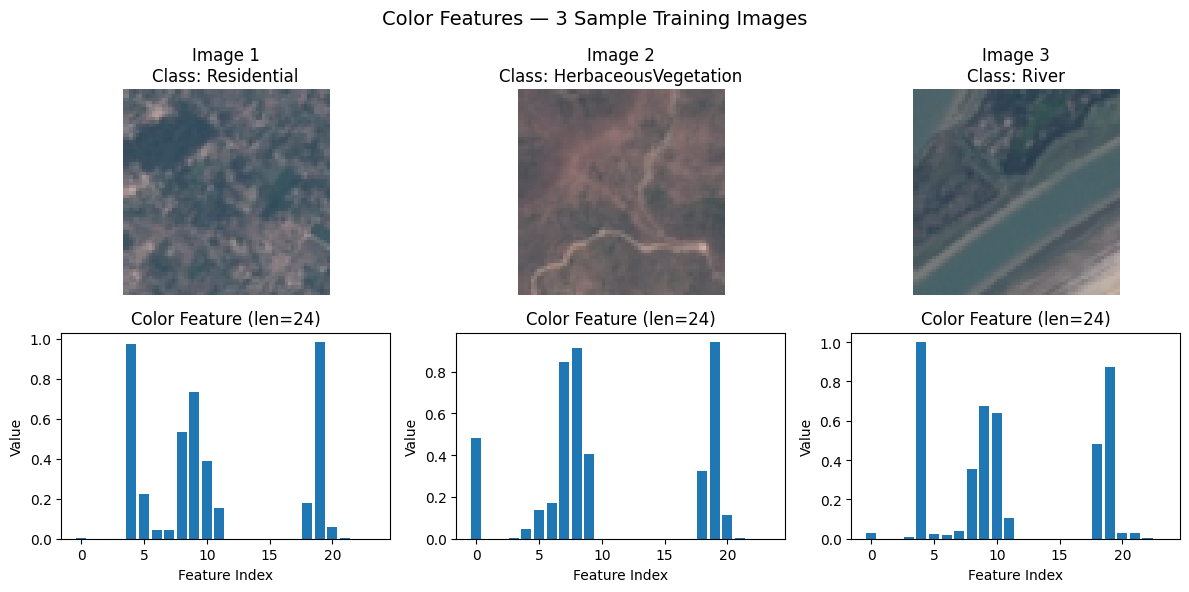

In [ ]:
def visualize_color_features_samples(df, base_dir, sample_indices, target_size=TARGET_SIZE):
    """
    Shows original images (top row) and color feature histograms (bottom row)
    for the same 3 sample images.
    """
    plt.figure(figsize=(12, 6))

    for pos, idx in enumerate(sample_indices):
        row = df.iloc[idx]
        img_path = os.path.join(base_dir, row["Filename"])
        img = cv2.imread(img_path)
        img = cv2.resize(img, target_size)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        color_feat = extract_color_feature(img)

        # Top row: original image
        plt.subplot(2, 3, pos + 1)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"Image {pos+1}\nClass: {row['ClassName']}")

        # Bottom row: color feature histogram
        plt.subplot(2, 3, pos + 4)
        plt.bar(np.arange(len(color_feat)), color_feat)
        plt.title(f"Color Feature (len={len(color_feat)})")
        plt.xlabel("Feature Index")
        plt.ylabel("Value")

    plt.suptitle("Color Features — 3 Sample Training Images", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_color_features_samples(train_df, DATASET, sample_indices)


#Visualize LBP features (3 images)

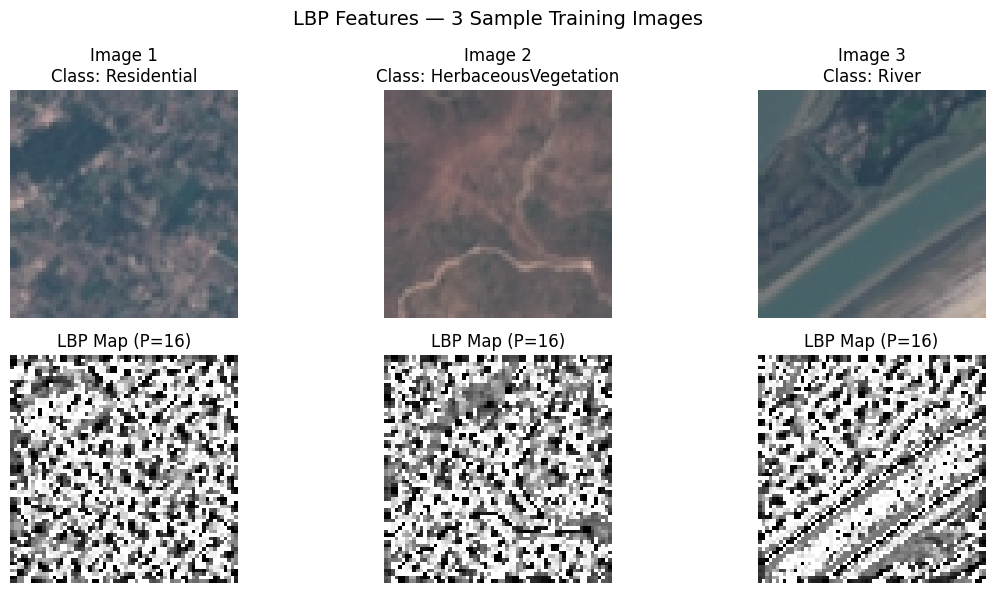

In [ ]:
def visualize_lbp_features_samples(df, base_dir, sample_indices, target_size=TARGET_SIZE):
    """
    Shows original images (top row) and LBP maps (bottom row)
    for the same 3 sample images.
    """
    plt.figure(figsize=(12, 6))

    for pos, idx in enumerate(sample_indices):
        row = df.iloc[idx]
        img_path = os.path.join(base_dir, row["Filename"])
        img = cv2.imread(img_path)
        img = cv2.resize(img, target_size)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method=LBP_METHOD)

        # Top row: original image
        plt.subplot(2, 3, pos + 1)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(f"Image {pos+1}\nClass: {row['ClassName']}")

        # Bottom row: LBP map
        plt.subplot(2, 3, pos + 4)
        plt.imshow(lbp, cmap="gray")
        plt.axis("off")
        plt.title(f"LBP Map (P={LBP_POINTS})")

    plt.suptitle("LBP Features — 3 Sample Training Images", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_lbp_features_samples(train_df, DATASET, sample_indices)


#Prepare Color / LBP / Fusion datasets for ANN

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
import joblib

# ======================================
# 1) Encode class labels once (shared)
# ======================================
label_enc = LabelEncoder()
y_train = label_enc.fit_transform(y_train_str)
y_val   = label_enc.transform(y_val_str)
y_test  = label_enc.transform(y_test_str)

class_names = label_enc.classes_
num_classes = len(class_names)
print("Classes:", class_names)
print("num_classes:", num_classes)

# One-hot labels (shared for all models)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val,   num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)


# ======================================
# 2) LBP features only
# ======================================
scaler_lbp = StandardScaler()
Xtr_lbp_scaled  = scaler_lbp.fit_transform(Xtr_lbp)
Xval_lbp_scaled = scaler_lbp.transform(Xval_lbp)
Xte_lbp_scaled  = scaler_lbp.transform(Xte_lbp)

joblib.dump(scaler_lbp, "lbp_scaler.pkl")
print("Saved LBP scaler → lbp_scaler.pkl")

print("LBP shapes (scaled):")
print("  Train:", Xtr_lbp_scaled.shape)
print("  Val:  ", Xval_lbp_scaled.shape)
print("  Test: ", Xte_lbp_scaled.shape)


# ======================================
# 3) Color features only
# ======================================
scaler_color = StandardScaler()
Xtr_color_scaled  = scaler_color.fit_transform(Xtr_color)
Xval_color_scaled = scaler_color.transform(Xval_color)
Xte_color_scaled  = scaler_color.transform(Xte_color)

joblib.dump(scaler_color, "color_scaler.pkl")
print("Saved Color scaler → color_scaler.pkl")

print("Color shapes (scaled):")
print("  Train:", Xtr_color_scaled.shape)
print("  Val:  ", Xval_color_scaled.shape)
print("  Test: ", Xte_color_scaled.shape)


# ======================================
# 4) Fusion = [Color || LBP]
# ======================================
Xtr_fusion  = np.concatenate([Xtr_color,  Xtr_lbp],  axis=1)
Xval_fusion = np.concatenate([Xval_color, Xval_lbp], axis=1)
Xte_fusion  = np.concatenate([Xte_color,  Xte_lbp],  axis=1)

print("Fusion raw shapes:")
print("  Train:", Xtr_fusion.shape)
print("  Val:  ", Xval_fusion.shape)
print("  Test: ", Xte_fusion.shape)

scaler_fusion = StandardScaler()
Xtr_fusion_scaled  = scaler_fusion.fit_transform(Xtr_fusion)
Xval_fusion_scaled = scaler_fusion.transform(Xval_fusion)
Xte_fusion_scaled  = scaler_fusion.transform(Xte_fusion)

joblib.dump(scaler_fusion, "fusion_scaler.pkl")
joblib.dump(label_enc,    "fusion_label_encoder.pkl")
print("Saved Fusion scaler → fusion_scaler.pkl")
print("Saved shared LabelEncoder → fusion_label_encoder.pkl")

print("Fusion shapes (scaled):")
print("  Train:", Xtr_fusion_scaled.shape)
print("  Val:  ", Xval_fusion_scaled.shape)
print("  Test: ", Xte_fusion_scaled.shape)


Classes: ['AnnualCrop' 'Forest' 'HerbaceousVegetation' 'Highway' 'Industrial'
 'Pasture' 'PermanentCrop' 'Residential' 'River' 'SeaLake']
num_classes: 10
Saved LBP scaler → lbp_scaler.pkl
LBP shapes (scaled):
  Train: (18900, 18)
  Val:   (5400, 18)
  Test:  (2700, 18)
Saved Color scaler → color_scaler.pkl
Color shapes (scaled):
  Train: (18900, 24)
  Val:   (5400, 24)
  Test:  (2700, 24)
Fusion raw shapes:
  Train: (18900, 42)
  Val:   (5400, 42)
  Test:  (2700, 42)
Saved Fusion scaler → fusion_scaler.pkl
Saved shared LabelEncoder → fusion_label_encoder.pkl
Fusion shapes (scaled):
  Train: (18900, 42)
  Val:   (5400, 42)
  Test:  (2700, 42)


#Build ANN model

In [ ]:
def build_ann_model(input_dim, num_classes):
    """
    Builds an ANN classifier with the same architecture
    for LBP, Color, and Fusion features.
    """
    model = Sequential([
        Input(shape=(input_dim,)),

        # Dense Layer 1
        Dense(
            256,
            activation='relu',
            kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)
        ),
        BatchNormalization(),
        Dropout(0.4),

        # Dense Layer 2
        Dense(
            128,
            activation='relu',
            kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)
        ),
        BatchNormalization(),
        Dropout(0.3),

        # Dense Layer 3 (smaller layer → reduces model complexity)
        Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        BatchNormalization(),
        Dropout(0.2),

        # Output layer
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


#ANN using LBP features only

Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5085 - loss: 1.5359 - val_accuracy: 0.7074 - val_loss: 0.8742 - learning_rate: 0.0010
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6496 - loss: 1.0319 - val_accuracy: 0.7157 - val_loss: 0.8359 - learning_rate: 0.0010
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6796 - loss: 0.9532 - val_accuracy: 0.7237 - val_loss: 0.8236 - learning_rate: 0.0010
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6807 - loss: 0.9555 - val_accuracy: 0.7200 - val_loss: 0.8246 - learning_rate: 0.0010
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6904 - loss: 0.9314 - val_accuracy: 0.7215 - val_loss: 0.8102 - learning_rate: 0.0010
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6995 - loss: 0.9104 - val_accuracy: 0.7267 - val_loss: 0.8085 - learning_rate: 0.0010
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7009 - loss: 0.8

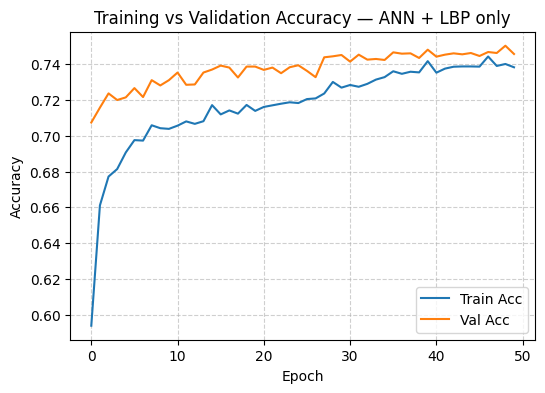

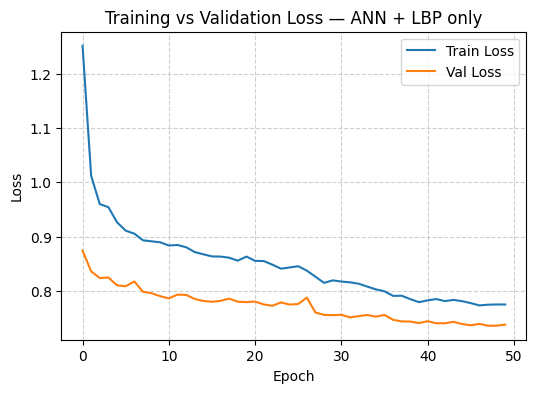

In [ ]:
# --- Model: ANN + LBP features only ---

input_dim_lbp = Xtr_lbp_scaled.shape[1]
model_lbp = build_ann_model(input_dim_lbp, num_classes)

es_lbp = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

rlr_lbp = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

hist_lbp = model_lbp.fit(
    Xtr_lbp_scaled, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(Xval_lbp_scaled, y_val_cat),
    callbacks=[es_lbp, rlr_lbp],
    verbose=1
)

# Test evaluation
test_loss_lbp, test_acc_lbp = model_lbp.evaluate(Xte_lbp_scaled, y_test_cat, verbose=0)
print(f"\nTest Accuracy (ANN + LBP only): {test_acc_lbp:.3f}")

y_prob_lbp = model_lbp.predict(Xte_lbp_scaled, verbose=0)
y_pred_lbp = np.argmax(y_prob_lbp, axis=1)
y_true = y_test

acc_lbp  = accuracy_score(y_true, y_pred_lbp)
prec_lbp = precision_score(y_true, y_pred_lbp, average='macro', zero_division=0)
rec_lbp  = recall_score(y_true, y_pred_lbp, average='macro', zero_division=0)
f1_lbp   = f1_score(y_true, y_pred_lbp, average='macro', zero_division=0)
cm_lbp   = confusion_matrix(y_true, y_pred_lbp)

print("\n=== Test Metrics (ANN + LBP only) ===")
print(f"Accuracy:  {acc_lbp:.3f}")
print(f"Precision: {prec_lbp:.3f}")
print(f"Recall:    {rec_lbp:.3f}")
print(f"F1-score:  {f1_lbp:.3f}\n")

print("=== Confusion Matrix (ANN + LBP only) ===")
print(cm_lbp)

# Training curves
plt.figure(figsize=(6, 4))
plt.plot(hist_lbp.history['accuracy'], label='Train Acc')
plt.plot(hist_lbp.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy — ANN + LBP only')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(hist_lbp.history['loss'], label='Train Loss')
plt.plot(hist_lbp.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss — ANN + LBP only')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#ANN using Color features only

Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4337 - loss: 1.7901 - val_accuracy: 0.6372 - val_loss: 1.0657 - learning_rate: 0.0010
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5994 - loss: 1.2092 - val_accuracy: 0.6793 - val_loss: 0.9624 - learning_rate: 0.0010
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6291 - loss: 1.1209 - val_accuracy: 0.6996 - val_loss: 0.9165 - learning_rate: 0.0010
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6477 - loss: 1.0540 - val_accuracy: 0.7076 - val_loss: 0.8870 - learning_rate: 0.0010
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6570 - loss: 1.0350 - val_accuracy: 0.7150 - val_loss: 0.8708 - learning_rate: 0.0010
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6735 - loss: 1.0052 - val_accuracy: 0.7213 - val_loss: 0.8483 - learning_rate: 0.0010
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6703 - loss: 0.9910 - 

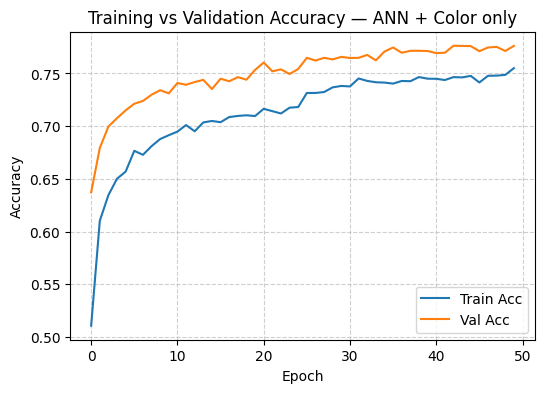

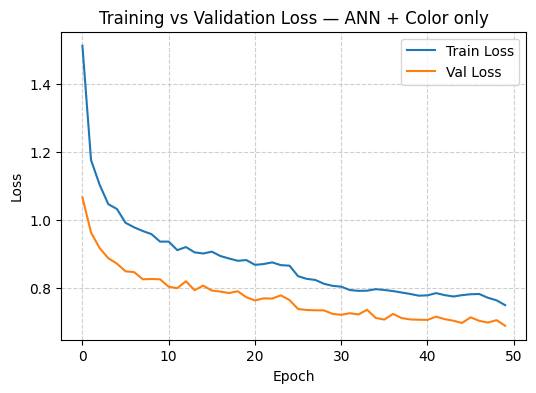

In [ ]:
# --- Model: ANN + Color features only ---

input_dim_color = Xtr_color_scaled.shape[1]
model_color = build_ann_model(input_dim_color, num_classes)

es_color = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

rlr_color = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

hist_color = model_color.fit(
    Xtr_color_scaled, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(Xval_color_scaled, y_val_cat),
    callbacks=[es_color, rlr_color],
    verbose=1
)

# Test evaluation
test_loss_color, test_acc_color = model_color.evaluate(Xte_color_scaled, y_test_cat, verbose=0)
print(f"\nTest Accuracy (ANN + Color only): {test_acc_color:.3f}")

y_prob_color = model_color.predict(Xte_color_scaled, verbose=0)
y_pred_color = np.argmax(y_prob_color, axis=1)
y_true = y_test

acc_color  = accuracy_score(y_true, y_pred_color)
prec_color = precision_score(y_true, y_pred_color, average='macro', zero_division=0)
rec_color  = recall_score(y_true, y_pred_color, average='macro', zero_division=0)
f1_color   = f1_score(y_true, y_pred_color, average='macro', zero_division=0)
cm_color   = confusion_matrix(y_true, y_pred_color)

print("\n=== Test Metrics (ANN + Color only) ===")
print(f"Accuracy:  {acc_color:.3f}")
print(f"Precision: {prec_color:.3f}")
print(f"Recall:    {rec_color:.3f}")
print(f"F1-score:  {f1_color:.3f}\n")

print("=== Confusion Matrix (ANN + Color only) ===")
print(cm_color)

# Training curves
plt.figure(figsize=(6, 4))
plt.plot(hist_color.history['accuracy'], label='Train Acc')
plt.plot(hist_color.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy — ANN + Color only')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(hist_color.history['loss'], label='Train Loss')
plt.plot(hist_color.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss — ANN + Color only')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#ANN + Color+LBP Fusion

Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5755 - loss: 1.3485 - val_accuracy: 0.8131 - val_loss: 0.5948 - learning_rate: 0.0010
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7678 - loss: 0.7373 - val_accuracy: 0.8348 - val_loss: 0.5346 - learning_rate: 0.0010
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7990 - loss: 0.6365 - val_accuracy: 0.8450 - val_loss: 0.5067 - learning_rate: 0.0010
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8071 - loss: 0.6241 - val_accuracy: 0.8494 - val_loss: 0.4847 - learning_rate: 0.0010
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8150 - loss: 0.5892 - val_accuracy: 0.8552 - val_loss: 0.4846 - learning_rate: 0.0010
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8268 - loss: 0.5709 - val_accuracy: 0.8596 - val_loss: 0.4779 - learning_rate: 0.0010
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8287 - loss: 0.56

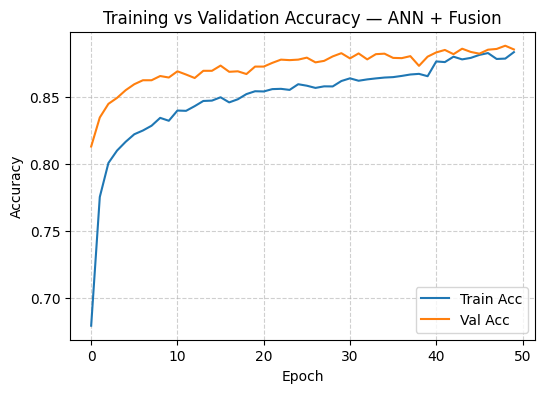

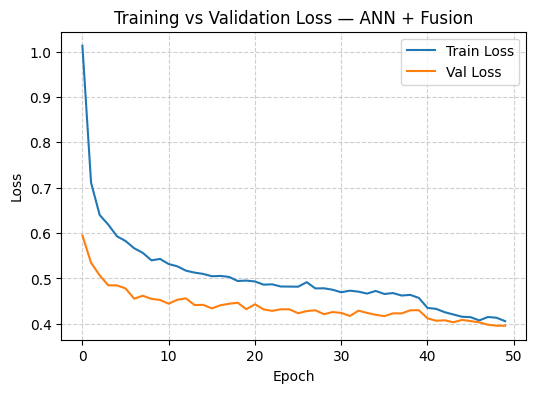

In [ ]:
# --- Model: ANN + Color+LBP Fusion ---

input_dim_fusion = Xtr_fusion_scaled.shape[1]
model_fusion = build_ann_model(input_dim_fusion, num_classes)

es_final = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

rlr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

hist_fusion = model_fusion.fit(
    Xtr_fusion_scaled, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(Xval_fusion_scaled, y_val_cat),
    callbacks=[es_final, rlr_final],
    verbose=1
)
#  Save weights
model_fusion.save_weights("ann_fusion.weights.h5")
print("Saved Fusion weights → ann_fusion.weights.h5")

model_fusion.save("ann_fusion_model.keras")
print("Saved Fusion full model → ann_fusion_model.keras")

# Test evaluation
test_loss_fusion, test_acc_fusion = model_fusion.evaluate(Xte_fusion_scaled, y_test_cat, verbose=0)
print(f"\nTest Accuracy (ANN + Color+LBP Fusion): {test_acc_fusion:.3f}")

y_test_prob = model_fusion.predict(Xte_fusion_scaled, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)
y_test_true = y_test

acc  = accuracy_score(y_test_true, y_test_pred)
prec = precision_score(y_test_true, y_test_pred, average='macro', zero_division=0)
rec  = recall_score(y_test_true, y_test_pred, average='macro', zero_division=0)
f1   = f1_score(y_test_true, y_test_pred, average='macro', zero_division=0)
cm   = confusion_matrix(y_test_true, y_test_pred)

print("\n=== Test Metrics (ANN + Color+LBP Fusion) ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}\n")

print("=== Test Classification Report ===")
print(classification_report(y_test_true, y_test_pred, target_names=class_names, digits=3))

print("=== Confusion Matrix (ANN + Color+LBP Fusion) ===")
print(cm)

# Training curves
plt.figure(figsize=(6, 4))
plt.plot(hist_fusion.history['accuracy'], label='Train Acc')
plt.plot(hist_fusion.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy — ANN + Fusion')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(hist_fusion.history['loss'], label='Train Loss')
plt.plot(hist_fusion.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss — ANN + Fusion')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#Test on random test images -fusion

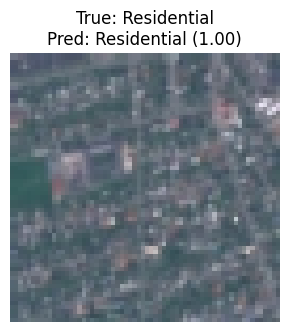

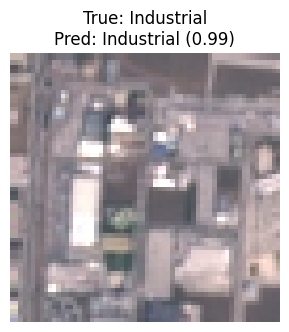

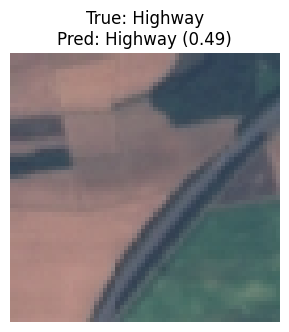

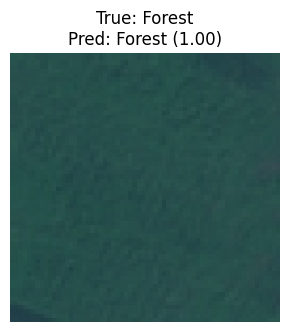

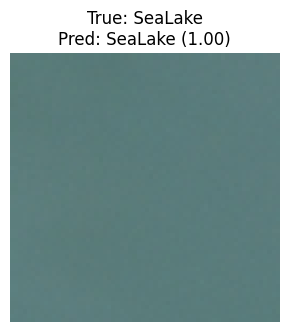

In [ ]:
import random
import matplotlib.pyplot as plt

def predict_fusion_from_img_array(img_bgr):
    """
    Takes a BGR image, extracts Color+LBP fusion features,
    scales them, and returns predicted class + confidence.
    """
    # Resize to match training
    img_resized = cv2.resize(img_bgr, (64, 64))

    # Extract features
    color_feat = extract_color_feature(img_resized)
    lbp_feat   = extract_lbp_feature(img_resized)

    fusion = np.concatenate([color_feat, lbp_feat]).reshape(1, -1)

    # Scale (use your fusion scaler name: scaler_fusion or scaler)
    fusion_scaled = scaler_fusion.transform(fusion)

    # Predict
    probs = model_fusion.predict(fusion_scaled, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = label_enc.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx]

    return pred_class, confidence

# Test on random N images from test set
N = 5  # change number of samples if you want
indices = random.sample(list(test_df.index), N)

for idx in indices:
    row = test_df.loc[idx]
    img_path = os.path.join(DATASET, row["Filename"])
    true_class = row["ClassName"]

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"[Warning] Could not read {img_path}, skipping.")
        continue

    pred_class, conf = predict_fusion_from_img_array(img_bgr)

    # Show image + true/pred
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(3.5, 3.5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"True: {true_class}\nPred: {pred_class} ({conf:.2f})")
    plt.show()


#Test on random test images — LBP

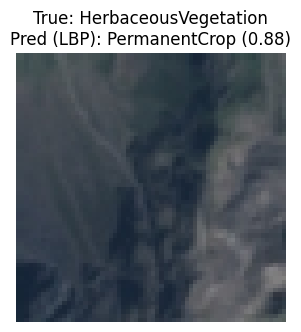

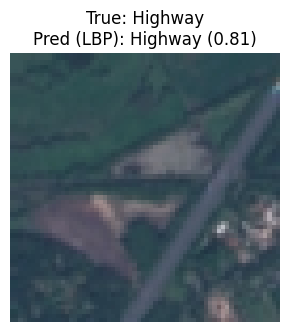

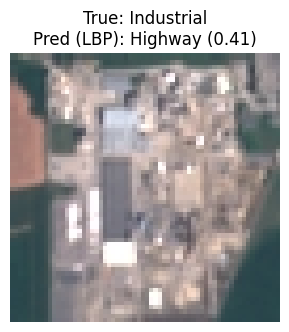

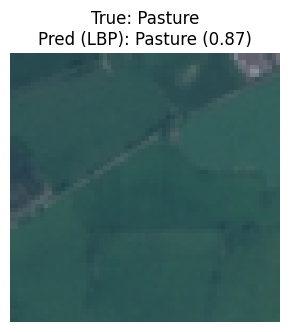

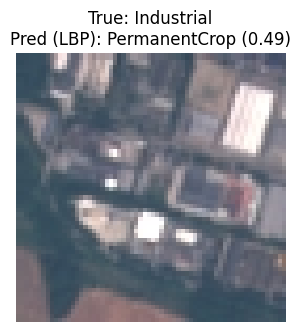

In [ ]:
import random
import matplotlib.pyplot as plt

def predict_lbp_from_img_array(img_bgr):
    """
    Takes a BGR image, extracts LBP features only,
    scales them, and returns predicted class + confidence.
    """
    img_resized = cv2.resize(img_bgr, (64, 64))

    lbp_feat = extract_lbp_feature(img_resized).reshape(1, -1)

    lbp_scaled = scaler_lbp.transform(lbp_feat)

    probs = model_lbp.predict(lbp_scaled, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = label_enc.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx]

    return pred_class, confidence


# Test on random N images from test set
N = 5
indices = random.sample(list(test_df.index), N)

for idx in indices:
    row = test_df.loc[idx]
    img_path = os.path.join(DATASET, row["Filename"])
    true_class = row["ClassName"]

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"[Warning] Could not read {img_path}, skipping.")
        continue

    pred_class, conf = predict_lbp_from_img_array(img_bgr)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(3.5, 3.5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"True: {true_class}\nPred (LBP): {pred_class} ({conf:.2f})")
    plt.show()


#Test on random test images — Color Model

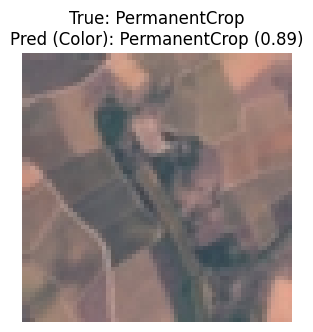

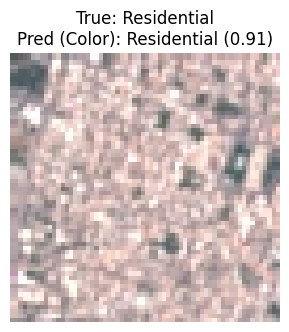

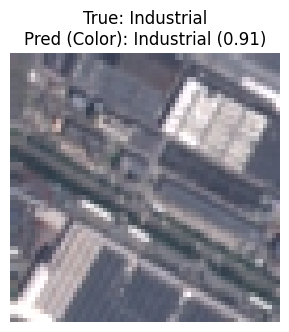

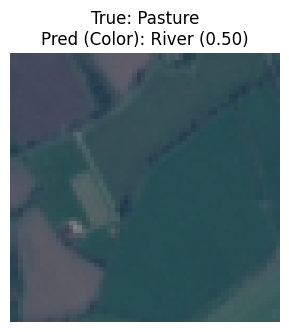

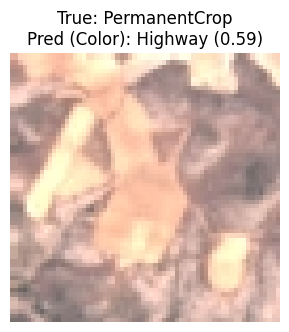

In [ ]:
import random
import matplotlib.pyplot as plt

def predict_color_from_img_array(img_bgr):
    """
    Takes a BGR image, extracts Color HSV histogram features only,
    scales them, and returns predicted class + confidence.
    """
    img_resized = cv2.resize(img_bgr, (64, 64))

    color_feat = extract_color_feature(img_resized).reshape(1, -1)

    color_scaled = scaler_color.transform(color_feat)

    probs = model_color.predict(color_scaled, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = label_enc.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx]

    return pred_class, confidence


# Test on random N images from test set
N = 5
indices = random.sample(list(test_df.index), N)

for idx in indices:
    row = test_df.loc[idx]
    img_path = os.path.join(DATASET, row["Filename"])
    true_class = row["ClassName"]

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"[Warning] Could not read {img_path}, skipping.")
        continue

    pred_class, conf = predict_color_from_img_array(img_bgr)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(3.5, 3.5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"True: {true_class}\nPred (Color): {pred_class} ({conf:.2f})")
    plt.show()


#Load Fusion Model + Scaler + Encoder

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
import joblib
import cv2
import numpy as np

# =============================
# Rebuild ANN Fusion architecture
# =============================
def build_ann_model(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# =============================
# Load scaler + encoder
# =============================
scaler = joblib.load("fusion_scaler.pkl")
label_enc = joblib.load("fusion_label_encoder.pkl")

num_classes = len(label_enc.classes_)

# =============================
# Build model + load weights
# =============================
input_dim = scaler.mean_.shape[0]
model_fusion = build_ann_model(input_dim, num_classes)
model_fusion.load_weights("ann_fusion.weights.h5")

print("Fusion model loaded!")
print("Input dim:", input_dim)
print("Classes:", label_enc.classes_)


Fusion model loaded!
Input dim: 42
Classes: ['AnnualCrop' 'Forest' 'HerbaceousVegetation' 'Highway' 'Industrial'
 'Pasture' 'PermanentCrop' 'Residential' 'River' 'SeaLake']


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saving Forest_1001.jpg to Forest_1001.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


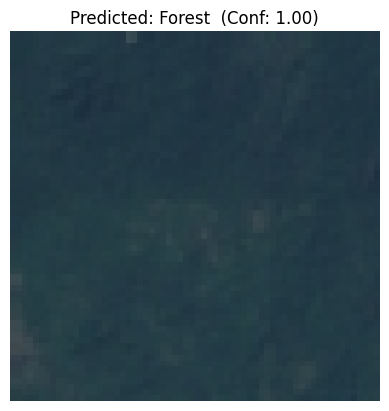


Prediction: Forest
Confidence: 0.9986243


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

def predict_fusion_image(img_path):
    # 1) Read + resize
    img = cv2.imread(img_path)
    img = cv2.resize(img, (64, 64))

    # 2) Extract color + LBP features
    color_feat = extract_color_feature(img)
    lbp_feat   = extract_lbp_feature(img)

    # 3) Fusion feature
    fusion = np.concatenate([color_feat, lbp_feat]).reshape(1, -1)

    # 4) Scale
    fusion_scaled = scaler.transform(fusion)

    # 5) Predict
    probs = model_fusion.predict(fusion_scaled)[0]
    pred_idx = np.argmax(probs)
    pred_class = label_enc.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx]

    # 6) Display image
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Predicted: {pred_class}  (Conf: {confidence:.2f})")
    plt.show()

    return pred_class, confidence



# Upload image from device
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predict
pred, conf = predict_fusion_image(img_path)
print("\nPrediction:", pred)
print("Confidence:", conf)
